# 1. Importing Data

In [1]:
#
import pandas as pd
import numpy as np

In [2]:
df_acc = pd.read_csv('moneycraft_accounts.csv')
df_acc['month'] = pd.PeriodIndex(df_acc['month'], freq='M')
df_acc.head()

,customer_id,month,acquisition_channel,region,age_band,account_tier,monthly_fee,joined_on_promo
0,1,2022-01,Comparison Site,Scotland,25-34,Classic,0,False
1,2,2022-01,Online,London,55-64,Silver,11,False
2,3,2022-01,Branch,South East,25-34,Platinum,28,False
3,4,2022-01,Referral,London,25-34,Silver,0,True
4,5,2022-01,Comparison Site,South East,35-44,Silver,11,False


In [3]:
df_mark = pd.read_csv('moneycraft_marketing_spend.csv')
df_mark['month'] = pd.PeriodIndex(df_mark['month'], freq='M')
df_mark.head()

,month,channel,spend_gbp
0,2022-01,Branch,7310.0
1,2022-01,Broker/IFA,4014.0
2,2022-01,Comparison Site,3162.0
3,2022-01,Online,3945.0
4,2022-01,Outbound,4899.0


In [27]:
df_clos = pd.read_csv('moneycraft_closure_reasons.csv')
df_clos['close_month'] = pd.PeriodIndex(df_clos['close_month'], freq='M')
df_clos.head()

,customer_id,close_month,reason_code
0,10755,2024-05,Switched provider
1,7582,2025-01,Unhappy with perks
2,2162,2024-11,Fees too high
3,3016,2023-02,Switched provider
4,564,2022-07,Poor service


# 2. Exploratory Analysis

In [4]:
switches = (df_acc.sort_values(['customer_id', 'month'])
                  .groupby('customer_id')['account_tier']
                  .apply(lambda s: (s != s.shift()).sum() - 1))

switches.head(20)

#Exploratory analysis to see number of switches in tier

customer_id
1     0
2     2
3     2
4     0
5     1
6     2
7     0
8     1
9     2
10    1
11    0
12    0
13    0
14    3
15    0
16    0
17    0
18    1
19    2
20    3
Name: account_tier, dtype: int64

In [5]:
df_acc['customer_id'].nunique()
#15732

15732

In [6]:
df_acc.dtypes

customer_id                int64
month                  period[M]
acquisition_channel       object
region                    object
age_band                  object
account_tier              object
monthly_fee                int64
joined_on_promo             bool
dtype: object

In [7]:
df_acc = df_acc.sort_values(['customer_id', 'month'])
df_acc

,customer_id,month,acquisition_channel,region,age_band,account_tier,monthly_fee,joined_on_promo
0,1,2022-01,Comparison Site,Scotland,25-34,Classic,0,False
280,1,2022-02,Comparison Site,Scotland,25-34,Classic,0,False
840,1,2022-03,Comparison Site,Scotland,25-34,Classic,0,False
1664,1,2022-04,Comparison Site,Scotland,25-34,Classic,0,False
2750,1,2022-05,Comparison Site,Scotland,25-34,Classic,0,False
...,...,...,...,...,...,...,...,...
179013,15728,2024-12,Outbound,Midlands,35-44,Silver,0,True
179014,15729,2024-12,Comparison Site,Midlands,25-34,Classic,0,True
179015,15730,2024-12,Referral,London,25-34,Gold,18,False
179016,15731,2024-12,Online,South East,55-64,Platinum,28,False


In [8]:
grouped = df_acc.groupby('customer_id')

# A few simple summaries, one per customer:
signup_month  = grouped['month'].min()    # their FIRST month
last_active   = grouped['month'].max()    # their LAST month
tenure_months = grouped['month'].count()  # how many months in total

signup_month.head()

customer_id
1    2022-01
2    2022-01
3    2022-01
4    2022-01
5    2022-01
Name: month, dtype: period[M]

In [9]:
grouped['joined_on_promo'].first()

customer_id
1        False
2        False
3        False
4         True
5        False
         ...  
15728     True
15729     True
15730    False
15731    False
15732     True
Name: joined_on_promo, Length: 15732, dtype: bool

In [10]:
channel    = grouped['acquisition_channel'].first() # Assuming they haven't rejoined using a different channel
region     = grouped['region'].first() # Assuming they haven't moved
age_band   = grouped['age_band'].first() # Assuming they haven't aged
first_plan = grouped['account_tier'].first()   # the plan they STARTED on
last_plan  = grouped['account_tier'].last()    # the plan they ENDED on
promo_join = grouped['joined_on_promo'].first() # whether they joined on promo


first_plan.head()

customer_id
1     Classic
2      Silver
3    Platinum
4      Silver
5      Silver
Name: account_tier, dtype: object

In [11]:
# 1. Identify where a tier change occurs
tier_changed = df_acc['account_tier'] != df_acc.groupby('customer_id')['account_tier'].shift()

# 2. Group into a clean Python list per customer
plan_history_list = df_acc[tier_changed].groupby('customer_id')['account_tier'].apply(list)
plan_history_list

customer_id
1                         [Classic]
2          [Silver, Gold, Platinum]
3        [Platinum, Gold, Platinum]
4                          [Silver]
5                 [Silver, Classic]
                    ...            
15728                      [Silver]
15729                     [Classic]
15730                        [Gold]
15731                    [Platinum]
15732                    [Platinum]
Name: account_tier, Length: 15732, dtype: object

In [12]:
total_revenue = grouped['monthly_fee'].sum()   # everything they ever paid us
max_paid      = grouped['monthly_fee'].max()   # the most they ever paid in a month

total_revenue.head()

customer_id
1      0
2    595
3    848
4    330
5     33
Name: monthly_fee, dtype: int64

# 3. Single Customer View Creation and Analysis

In [39]:
scv = pd.DataFrame({
    'signup_month' : signup_month,
    'last_active'  : last_active,
    'tenure_months': tenure_months,
    'channel'      : channel,
    'region'       : region,
    'age_band'     : age_band,
    'first_plan'   : first_plan,
    'last_plan'    : last_plan,
    'total_revenue': total_revenue,
    'promo_join'   : promo_join,
    'plan_history' : plan_history_list
})

# A handy True/False column: did they EVER actually pay us?
scv['ever_paid'] = max_paid > 0

scv.head()

,signup_month,last_active,tenure_months,channel,region,age_band,first_plan,last_plan,total_revenue,promo_join,plan_history,ever_paid
customer_id,,,,,,,,,,,,
1,2022-01,2022-06,6,Comparison Site,Scotland,25-34,Classic,Classic,0,False,[Classic],False
2,2022-01,2024-12,36,Online,London,55-64,Silver,Platinum,595,False,"[Silver, Gold, Platinum]",True
3,2022-01,2024-12,36,Branch,South East,25-34,Platinum,Platinum,848,False,"[Platinum, Gold, Platinum]",True
4,2022-01,2024-12,36,Referral,London,25-34,Silver,Silver,330,True,[Silver],True
5,2022-01,2022-10,10,Comparison Site,South East,35-44,Silver,Classic,33,False,"[Silver, Classic]",True


In [40]:
# 1. Define the condition for successful promo retention
is_promo = scv['promo_join'] == True
stayed_past_free = scv['tenure_months'] > 6

# 2. Use np.where: True if retained, False if they left early, None/NaN if not a promo customer
scv['retained_after_promo'] = np.where(is_promo, stayed_past_free, None)

In [41]:
final_month = df_acc['month'].max()          # the last month we can see in the data
print('Final month in the data:', final_month)

scv['churned'] = scv['last_active'] < final_month   # True if they left before the end
scv[['signup_month', 'last_active', 'tenure_months', 'churned']].head()

Final month in the data: 2024-12


,signup_month,last_active,tenure_months,churned
customer_id,,,,
1,2022-01,2022-06,6,True
2,2022-01,2024-12,36,False
3,2022-01,2024-12,36,False
4,2022-01,2024-12,36,False
5,2022-01,2022-10,10,True


In [42]:
scv.head()

,signup_month,last_active,tenure_months,channel,region,age_band,first_plan,last_plan,total_revenue,promo_join,plan_history,ever_paid,retained_after_promo,churned
customer_id,,,,,,,,,,,,,,
1,2022-01,2022-06,6,Comparison Site,Scotland,25-34,Classic,Classic,0,False,[Classic],False,None,True
2,2022-01,2024-12,36,Online,London,55-64,Silver,Platinum,595,False,"[Silver, Gold, Platinum]",True,None,False
3,2022-01,2024-12,36,Branch,South East,25-34,Platinum,Platinum,848,False,"[Platinum, Gold, Platinum]",True,None,False
4,2022-01,2024-12,36,Referral,London,25-34,Silver,Silver,330,True,[Silver],True,True,False
5,2022-01,2022-10,10,Comparison Site,South East,35-44,Silver,Classic,33,False,"[Silver, Classic]",True,None,True


In [43]:
first = df_acc.sort_values('month').drop_duplicates('customer_id')
joiners = first.groupby(['month', 'acquisition_channel']).size()

spend = df_mark.set_index(['month', 'channel'])['spend_gbp']

cac = (spend / joiners).round(2).unstack()
cac.tail()

channel,Branch,Broker/IFA,Comparison Site,Online,Outbound,Referral
month,,,,,,
2024-08,157.33,209.86,43.32,71.28,118.40,58.66
2024-09,139.43,216.32,42.31,71.39,117.58,61.32
2024-10,156.00,207.53,41.88,71.73,122.77,54.82
2024-11,147.09,199.37,39.31,74.88,121.65,58.73
2024-12,153.36,197.85,39.55,68.74,128.36,62.77


In [44]:
df_LTV = df_acc.copy().groupby('customer_id')['monthly_fee'].sum().reset_index().sort_values('customer_id')
df_LTV.rename(columns={'monthly_fee': 'lifetime_value'}, inplace=True)
df_LTV.head()

,customer_id,lifetime_value
0,1,0
1,2,595
2,3,848
3,4,330
4,5,33


In [45]:
# 1. tenure per customer — needs the monthly panel, scv can't provide it
acc = df_acc.sort_values(['customer_id', 'month']).copy()
acc['tenure'] = acc.groupby('customer_id').cumcount()

# 2. eligibility comes straight from scv
eligible = scv.index[scv['signup_month'] <= '2024-01']
first12 = acc[acc['customer_id'].isin(eligible) & (acc['tenure'] < 12)]

# 3. first-12-month value, joined back onto scv
scv['value_12m'] = first12.groupby('customer_id')['monthly_fee'].sum()

# 4. CAC per channel
joiners = scv['channel'].value_counts()
cac = df_mark.groupby('channel')['spend_gbp'].sum() / joiners
scv['CAC'] = scv['channel'].map(cac.round(2))

# 5. summary table
out = pd.DataFrame({'value_12m': scv.groupby('channel')['value_12m'].mean().round(2),
                    'CAC': cac.round(2)})
out['ratio'] = (out.value_12m / out.CAC).round(2)
out = out.sort_values('ratio', ascending=False)

# 6. Tableau export — eligible customers only, old column names kept
df_tableau = scv[scv['value_12m'].notna()].copy()
df_tableau['cohort'] = df_tableau['signup_month'].dt.year.astype(str)
df_tableau['signup_month'] = df_tableau['signup_month'].dt.to_timestamp()
df_tableau['value_12m'] = df_tableau['value_12m'].astype(int)
df_tableau = df_tableau[['signup_month', 'cohort', 'channel', 'region', 'age_band',
                         'first_plan', 'promo_join', 'tenure_months', 'churned',
                         'value_12m', 'CAC']].reset_index()
df_tableau = df_tableau.rename(columns={'signup_month': 'join_month',
                                        'promo_join': 'promo',
                                        'first_plan': 'tier_at_join'})
df_tableau.to_csv('tableau_customer_value.csv', index=False)

In [46]:
# 1. churners come straight from scv
churners = scv[scv['churned']]

# 2. attach the reason — inner join keeps only churners who have one
df_reasons = churners.join(df_clos.set_index('customer_id')['reason_code'], how='inner')
df_reasons['promo_group'] = df_reasons['promo_join'].map({True: 'Joined on promo', False: 'No promo'})

# 3. tidy to the columns Tableau needs, with the old names
df_reasons = (df_reasons[['promo_join', 'channel', 'region', 'age_band', 'first_plan',
                          'tenure_months', 'reason_code', 'promo_group']]
              .rename(columns={'promo_join': 'promo',
                               'tenure_months': 'tenure',
                               'first_plan': 'tier_at_join'})
              .reset_index())
df_reasons.to_csv('tableau_closure_reasons.csv', index=False)

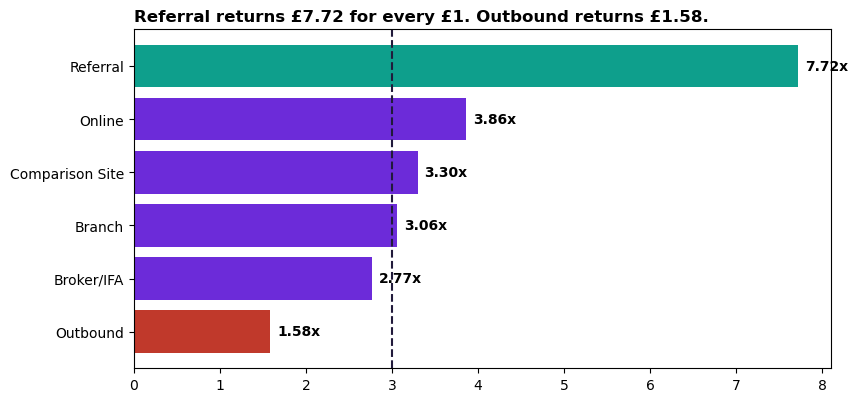

In [31]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt

acc = pd.read_csv("moneycraft_accounts.csv")
acc["month"] = pd.PeriodIndex(acc["month"], freq="M")
acc = acc.sort_values(["customer_id", "month"])

# one row per customer; churn = their rows stop before Dec 2024
g = acc.groupby("customer_id")
scv = pd.DataFrame({"tenure": g["month"].count(),
                    "channel": g["acquisition_channel"].first(),
                    "signup":  g["month"].min()})
scv["churned"] = g["month"].max() < acc["month"].max()

# 211 customers have a closure logged for Jan 2025 -> churned, not survivors
closed = pd.read_csv("moneycraft_closure_reasons.csv")
scv.loc[scv.index.isin(closed.customer_id) & ~scv.churned, "churned"] = True

# CAC = 3-year spend / customers won
spend = pd.read_csv("moneycraft_marketing_spend.csv").groupby("channel").spend_gbp.sum()
cac = spend / scv.groupby("channel").size()

# Kaplan-Meier: P(still open at month t), recent joiners censored
def km(sub, H=36):
    T, E, s, out = sub["tenure"].values, sub["churned"].values, 1.0, []
    for t in range(1, H + 1):
        s *= 1 - ((T == t) & E).sum() / max((T >= t).sum(), 1)
        out.append(s)
    return np.array(out)
S = {c: km(sub) for c, sub in scv.groupby("channel")}

# fee by tenure month (rises as waivers end), then LTV = sum of S(t) x fee(t)
acc["ten"] = acc.groupby("customer_id").cumcount() + 1
acc["ch"]  = acc["customer_id"].map(scv["channel"])
fee = acc[acc.ten <= 36].pivot_table(index="ten", columns="ch",
                                     values="monthly_fee", aggfunc="mean")
ltv   = pd.Series({c: (S[c] * fee[c].values).sum() for c in S})
ratio = (ltv / cac).sort_values()

# plot
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.barh(ratio.index, ratio.values,
        color=["#C0392B" if v < 2 else "#0E9F8C" if v >= 5 else "#6C2BD9"
               for v in ratio])
ax.axvline(3, ls="--", color="#211A3B")           # healthy-channel bar
for c, v in ratio.items():
    ax.text(v + .08, c, f"{v:.2f}x", va="center", fontweight="bold")
ax.set_title("Referral returns £7.72 for every £1. Outbound returns £1.58.",
             loc="left", fontweight="bold")
plt.show()

In [35]:
first = df_acc.sort_values('month').drop_duplicates('customer_id')
classic_promo = first[(first.account_tier == 'Classic') & (first.joined_on_promo)]

classic_promo.head(20)

,customer_id,month,acquisition_channel,region,age_band,account_tier,monthly_fee,joined_on_promo
200,201,2022-01,Comparison Site,South East,35-44,Classic,0,True
217,218,2022-01,Online,London,55-64,Classic,0,True
191,192,2022-01,Outbound,South East,55-64,Classic,0,True
162,163,2022-01,Online,South East,35-44,Classic,0,True
165,166,2022-01,Online,London,55-64,Classic,0,True
24,25,2022-01,Branch,North,45-54,Classic,0,True
166,167,2022-01,Comparison Site,Scotland,18-24,Classic,0,True
177,178,2022-01,Comparison Site,South East,35-44,Classic,0,True
12,13,2022-01,Comparison Site,London,25-34,Classic,0,True
275,276,2022-01,Outbound,North,35-44,Classic,0,True


In [36]:
df_acc.loc[df_acc['account_tier'] == 'Classic', 'monthly_fee'].sum()

np.int64(0)

In [37]:
acc = pd.read_csv("moneycraft_accounts.csv")
acc["month"] = pd.PeriodIndex(acc["month"], freq="M")
acc = acc.sort_values(["customer_id", "month"])
g = acc.groupby("customer_id")

scv = pd.DataFrame({
    "tenure": g["month"].count(),
    "channel": g["acquisition_channel"].first(),
})
scv["churned"] = g["month"].max() < acc["month"].max()

closures = pd.read_csv("moneycraft_closure_reasons.csv")
late = scv.index.isin(closures.customer_id) & ~scv.churned
scv.loc[late, "churned"] = True
print(f"customers: {len(scv):,}  |  late closures reclassified: {late.sum()}")

spend = pd.read_csv("moneycraft_marketing_spend.csv").groupby("channel").spend_gbp.sum()
acc["ten"] = acc.groupby("customer_id").cumcount() + 1

def kaplan_meier(sub, horizon=36):
    T, E = sub.tenure.values, sub.churned.values
    s, out = 1.0, []
    for t in range(1, horizon + 1):
        at_risk = (T >= t).sum()
        s *= 1 - ((T == t) & E).sum() / max(at_risk, 1)
        out.append(s)
    return np.array(out)

bubble_rows, surv_rows = [], []
for ch, sub in scv.groupby("channel"):
    surv = kaplan_meier(sub)
    a = acc[(acc.acquisition_channel == ch) & (acc.ten <= 36)]
    fee_t = a.groupby("ten").monthly_fee.mean().reindex(range(1, 37)).ffill().values
    ltv = float((surv * fee_t).sum())
    cac = spend[ch] / len(sub)
    bubble_rows.append({
        "channel": ch,
        "customers": len(sub),
        "cac": round(cac, 2),
        "ltv_36m": round(ltv, 2),
        "net_value_per_customer": round(ltv - cac, 2),
        "ltv_to_cac": round(ltv / cac, 2),
    })
    for m, s in enumerate(surv, start=1):
        # at-risk count shows where the curve gets thin (shade months where it is small)
        surv_rows.append({
            "channel": ch,
            "months_since_joining": m,
            "still_open_pct": round(s * 100, 1),
            "at_risk": int((sub.tenure.values >= m).sum()),
        })

pd.DataFrame(bubble_rows).to_csv("tableau_bubble_chart.csv", index=False)
pd.DataFrame(surv_rows).to_csv("tableau_survival_curves.csv", index=False)

customers: 15,732  |  late closures reclassified: 211
